In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/ishanmanglik/div2k/tensor_x.npy
/kaggle/input/notebooks/ishanmanglik/div2k/__results__.html
/kaggle/input/notebooks/ishanmanglik/div2k/val_tensor_x.npy
/kaggle/input/notebooks/ishanmanglik/div2k/__notebook__.ipynb
/kaggle/input/notebooks/ishanmanglik/div2k/__output__.json
/kaggle/input/notebooks/ishanmanglik/div2k/val_tensor_y.npy
/kaggle/input/notebooks/ishanmanglik/div2k/tensor_y.npy
/kaggle/input/notebooks/ishanmanglik/div2k/custom.css
/kaggle/input/notebooks/ishanmanglik/div2k/__results___files/__results___29_1.png
/kaggle/input/notebooks/ishanmanglik/div2k/__results___files/__results___26_3.png
/kaggle/input/notebooks/ishanmanglik/div2k/__results___files/__results___26_2.png
/kaggle/input/notebooks/ishanmanglik/div2k/__results___files/__results___12_1.png
/kaggle/input/notebooks/ishanmanglik/div2k/__results___files/__results___26_4.png
/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR/0857.png
/kaggle/input/data

In [59]:
!git clone https://github.com/JingyunLiang/SwinIR.git
import sys
sys.path.append('./SwinIR')

fatal: destination path 'SwinIR' already exists and is not an empty directory.


In [60]:
!pip install timm einops

In [61]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if len(files) > 0:
        print(files[:5])   # show first 5 files

/kaggle/input
/kaggle/input/notebooks
/kaggle/input/notebooks/ishanmanglik
/kaggle/input/notebooks/ishanmanglik/div2k
['tensor_x.npy', '__results__.html', 'val_tensor_x.npy', '__notebook__.ipynb', '__output__.json']
/kaggle/input/notebooks/ishanmanglik/div2k/__results___files
['__results___29_1.png', '__results___26_3.png', '__results___26_2.png', '__results___12_1.png', '__results___26_4.png']
/kaggle/input/datasets
/kaggle/input/datasets/soumikrakshit
/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images
/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR
/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR
['0857.png', '0816.png', '0835.png', '0889.png', '0834.png']
/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR
/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR
['0566.png', '0115.png', '0050.png', '0501.png', '0263.png']


In [62]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import glob
import os

class SRDataset(Dataset):
    def __init__(self, hr_folder, scale=4):
        self.hr_paths = sorted(glob.glob(os.path.join(hr_folder, "*.png")))
        self.scale = scale
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        hr = Image.open(self.hr_paths[idx]).convert("RGB")

        # Generate LR image using bicubic downsampling
        lr = hr.resize(
            (hr.width // self.scale, hr.height // self.scale),
            Image.BICUBIC
        )

        return self.to_tensor(lr), self.to_tensor(hr)

In [63]:
hr_folder = "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR"

train_dataset = SRDataset(hr_folder)

In [64]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import glob
import os

class SRDataset(Dataset):
    def __init__(self, hr_folder, scale=4):
        self.hr_paths = sorted(glob.glob(os.path.join(hr_folder, "*.png")))
        self.scale = scale

        self.hr_transform = transforms.Compose([
            transforms.Resize((256, 256)),   # Make every HR image 256×256
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        hr = Image.open(self.hr_paths[idx]).convert("RGB")
        hr = self.hr_transform(hr)

        lr = transforms.functional.resize(
            hr,
            [64, 64],
            interpolation=transforms.InterpolationMode.BICUBIC
        )

        return lr, hr

In [65]:
hr_folder = "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR"

train_dataset = SRDataset(hr_folder)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

In [66]:
lr_img, hr_img = next(iter(train_loader))

print(lr_img.shape)
print(hr_img.shape)

torch.Size([4, 3, 64, 64])
torch.Size([4, 3, 256, 256])


In [67]:
from models.network_swinir import SwinIR

model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6],
    embed_dim=60,
    num_heads=[6, 6, 6, 6],
    mlp_ratio=2,
    upsampler='pixelshuffle',
    resi_connection='1conv'
)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [69]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [70]:
lr_img = lr_img.to(device)

with torch.no_grad():
    sr_img = model(lr_img)

print(sr_img.shape)

torch.Size([4, 3, 256, 256])


In [75]:
import torch.nn as nn

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loss_fn = nn.L1Loss()

num_epochs = 10    # <-- Define number of epochs here

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    for lr_img, hr_img in train_loader:

        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        sr_img = model(lr_img)

        loss = loss_fn(sr_img, hr_img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss/len(train_loader):.4f}")

    torch.save(
        model.state_dict(),
        f"/kaggle/working/swinir_epoch_{epoch+1}.pth"
    )

Epoch 1/10 Loss: 0.0465
Epoch 2/10 Loss: 0.0432
Epoch 3/10 Loss: 0.0432
Epoch 4/10 Loss: 0.0425
Epoch 5/10 Loss: 0.0427
Epoch 6/10 Loss: 0.0429
Epoch 7/10 Loss: 0.0420
Epoch 8/10 Loss: 0.0424
Epoch 9/10 Loss: 0.0412
Epoch 10/10 Loss: 0.0409


In [76]:
torch.save(model.state_dict(), "/kaggle/working/swinir_x4_final.pth")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03783682..1.0922056].


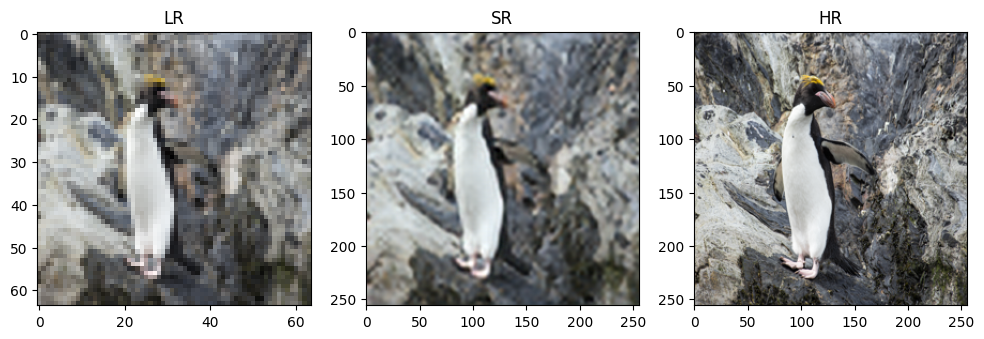

In [77]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR/0801.png"

hr = Image.open(img_path).convert("RGB")
hr = hr.resize((256,256))

lr = hr.resize((64,64), Image.BICUBIC)

to_tensor = transforms.ToTensor()

lr_tensor = to_tensor(lr).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    sr = model(lr_tensor)

sr = sr.squeeze().cpu().permute(1,2,0).numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(lr)
plt.title("LR")

plt.subplot(1,3,2)
plt.imshow(sr)
plt.title("SR")

plt.subplot(1,3,3)
plt.imshow(hr)
plt.title("HR")

plt.show()

In [78]:
!pip install scikit-image

In [79]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity